In [1]:
# Notebook 03 — Review response: tree canopy as a mediator of the flood-irrigation cooling effect
# Reviewer's question: is the cooling in canal-dense tracts caused by the water itself,
# or by the vegetation the irrigation supports? Canopy data lets us test that.

!pip install pygeohydro rasterstats rioxarray
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

SEED = 42

# Resolve project root (same pattern as Notebooks 01 and 02)
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

# Load the canonical analysis output from Notebook 02 (clusters, UHI, demographics, canal features)
tracts = gpd.read_file(ROOT / 'data' / 'processed' / 'tracts_analyzed.gpkg')
print(f'Loaded {len(tracts)} tracts | CRS: {tracts.crs.to_string()}')
print(f'Columns: {list(tracts.columns)}')

# Confirm clusters and key fields came through
print(f'\nClustered tracts: {tracts["cluster"].notna().sum()}')
print('\nArchetype counts:')
print(tracts['archetype'].value_counts().to_string())

Loaded 671 tracts | CRS: EPSG:4269
Columns: ['GEOID', 'uhi_index_f', 'uhi_index_c', 'nearest_canal_mi', 'canal_mi_in_tract', 'canal_per_mi2', 'area_mi2', 'median_year_built', 'median_hh_income', 'median_home_value', 'median_rent', 'pct_white', 'pct_black', 'pct_hispanic', 'pct_owner_occupied', 'pop_total', 'cluster', 'archetype', 'geometry']

Clustered tracts: 642

Archetype counts:
archetype
Newer middle/upper-class suburbs          260
Older Hispanic urban core                 232
Working-class Hispanic, canal-adjacent    143
Outer-ring exurbs                           7


In [2]:
# Cell 2 — Acquire NLCD Tree Canopy Cover (2021) for the study area.
# pygeohydro pulls from the MRLC service and handles the pixel-limit chunking internally.
# One-time install if needed:
#   pip install pygeohydro rasterstats rioxarray
import warnings; warnings.filterwarnings('ignore')
from shapely.geometry import box
import pygeohydro as gh
import rioxarray

# Bounding box over all study-area tracts, in EPSG:4326 for the MRLC request
bounds_4326 = tracts.to_crs('EPSG:4326').total_bounds  # [minx, miny, maxx, maxy]
aoi = gpd.GeoDataFrame({'id': [0]}, geometry=[box(*bounds_4326)], crs='EPSG:4326')
print(f'AOI bounds (lon/lat): {bounds_4326.round(4)}')

# Fetch tree canopy at 30 m. The metro is large, so the library splits it into a few
# sub-requests and merges them. Expect roughly 1-3 minutes.
print('Fetching NLCD tree canopy 2021 (this can take a couple of minutes)...')
res = gh.nlcd_bygeom(aoi, resolution=30, years={'canopy': [2021]})
canopy = res[0]['canopy_2021'].rio.write_crs('EPSG:4326')

# NLCD canopy is 0-100%; mask anything above 100 as fill/non-data
canopy = canopy.where(canopy <= 100)

# Save to GeoTIFF for the zonal-stats step
canopy_path = ROOT / 'data' / 'raw' / 'nlcd_canopy_2021_phoenix.tif'
canopy.rio.to_raster(canopy_path)

vals = canopy.values.astype('float')
print(f'Canopy raster shape: {canopy.shape}')
print(f'Canopy % across study area — min {np.nanmin(vals):.1f}, '
      f'mean {np.nanmean(vals):.1f}, max {np.nanmax(vals):.1f}')
print(f'Saved to {canopy_path}')

AOI bounds (lon/lat): [-112.7463   33.2047 -111.0399   34.0482]
Fetching NLCD tree canopy 2021 (this can take a couple of minutes)...
Canopy raster shape: (3119, 5304)
Canopy % across study area — min 0.0, mean 3.1, max 77.0
Saved to /Users/seanjayasekera/Documents/Data Science Projects/Hohokam Pattern/data/raw/nlcd_canopy_2021_phoenix.tif


In [3]:
# Cell 3 (revised) — diagnose alignment, then compute mean canopy per tract robustly
import rasterio
from rasterstats import zonal_stats

canopy_path = ROOT / 'data' / 'raw' / 'nlcd_canopy_2021_phoenix.tif'

# 1. Read the raster's true CRS, transform, and bounds
with rasterio.open(canopy_path) as src:
    arr     = src.read(1)
    affine  = src.transform
    rcrs    = src.crs
    nod     = src.nodata
    rbounds = src.bounds
print('Raster CRS   :', rcrs)
print('Raster bounds:', tuple(round(b, 3) for b in rbounds))
print('Raster nodata:', nod, '| dtype:', arr.dtype)

# 2. Reproject tracts to the raster's ACTUAL crs and compare bounds (sanity check)
tracts_r = tracts.to_crs(rcrs)
print('\nTracts CRS   :', tracts.crs, '-> reprojected to', rcrs)
print('Tracts bounds:', tuple(round(b, 3) for b in tracts_r.total_bounds))

# 3. Zonal stats with the array + affine pattern (no path/CRS ambiguity)
stats = zonal_stats(tracts_r.geometry, arr, affine=affine, nodata=nod,
                    stats=['mean', 'count'])
tracts['canopy_pct'] = [s['mean']  for s in stats]
tracts['canopy_px']  = [s['count'] for s in stats]

n_valid = tracts['canopy_pct'].notna().sum()
print(f'\nTracts with a canopy value: {n_valid} / {len(tracts)}')
print(f'Tracts with zero valid pixels: {(tracts["canopy_px"] == 0).sum()}')
if n_valid:
    print('\nCanopy % distribution across tracts:')
    print(tracts['canopy_pct'].describe().round(2).to_string())
    print('\nMean canopy % by archetype:')
    print(tracts.groupby('archetype')['canopy_pct']
          .agg(['mean', 'median', 'count']).round(2).to_string())

Raster CRS   : EPSG:4326
Raster bounds: (-112.746, 33.205, -111.04, 34.048)
Raster nodata: nan | dtype: float32

Tracts CRS   : EPSG:4269 -> reprojected to EPSG:4326
Tracts bounds: (np.float64(-112.746), np.float64(33.205), np.float64(-111.04), np.float64(34.048))

Tracts with a canopy value: 671 / 671
Tracts with zero valid pixels: 0

Canopy % distribution across tracts:
count    671.00
mean       0.92
std        0.84
min        0.00
25%        0.43
50%        0.74
75%        1.08
max        7.23

Mean canopy % by archetype:
                                        mean  median  count
archetype                                                  
Newer middle/upper-class suburbs        1.02    0.76    260
Older Hispanic urban core               0.91    0.76    232
Outer-ring exurbs                       0.39    0.20      7
Working-class Hispanic, canal-adjacent  0.82    0.74    143


In [4]:
# Cell 4 — Does tree canopy explain the flood-irrigation cooling?
from scipy import stats as st

# Dependency-free OLS with p-values (numpy + scipy only)
def ols(y, X, names):
    X = np.column_stack([np.ones(len(y)), np.asarray(X, float)])
    names = ['intercept'] + names
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    n, k = X.shape
    sigma2 = (resid @ resid) / (n - k)
    cov = sigma2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(cov))
    t = beta / se
    p = 2 * st.t.sf(np.abs(t), n - k)
    return {nm: (b, s, pv) for nm, b, s, pv in zip(names, beta, se, p)}

# (a) Overall association: canopy vs UHI across all tracts
s = tracts.dropna(subset=['canopy_pct', 'uhi_index_f'])
r, pr  = st.pearsonr(s['canopy_pct'], s['uhi_index_f'])
rho, _ = st.spearmanr(s['canopy_pct'], s['uhi_index_f'])
print(f'(a) Canopy vs UHI across {len(s)} tracts: '
      f'Pearson r = {r:.3f} (p = {pr:.3g}), Spearman rho = {rho:.3f}')

# (b) The decisive comparison: the two Hispanic clusters
core  = tracts[tracts['archetype'] == 'Older Hispanic urban core']
canal = tracts[tracts['archetype'] == 'Working-class Hispanic, canal-adjacent']
print('\n(b) Two Hispanic clusters:')
print(f"    Urban core (hotter):     UHI {core['uhi_index_f'].mean():.2f} °F, canopy {core['canopy_pct'].mean():.2f}%")
print(f"    Canal-adjacent (cooler): UHI {canal['uhi_index_f'].mean():.2f} °F, canopy {canal['canopy_pct'].mean():.2f}%")
tt, ptt = st.ttest_ind(canal['canopy_pct'].dropna(), core['canopy_pct'].dropna(), equal_var=False)
cdiff = canal['canopy_pct'].mean() - core['canopy_pct'].mean()
print(f"    Canopy difference (cooler - hotter): {cdiff:+.2f}%  (Welch t = {tt:.2f}, p = {ptt:.3g})")
print('    -> If canopy drove the cooling, the cooler cluster should be LEAFIER. It is not.')

# (c) Mediation check: does controlling for canopy shrink the ~0.58 deg cooling gap?
two = tracts[tracts['archetype'].isin([
    'Older Hispanic urban core', 'Working-class Hispanic, canal-adjacent'])].copy()
two['canal_adjacent'] = (two['archetype'] == 'Working-class Hispanic, canal-adjacent').astype(float)
two = two.dropna(subset=['uhi_index_f', 'canopy_pct'])

y = two['uhi_index_f'].values
m1 = ols(y, two[['canal_adjacent']].values, ['canal_adjacent'])
m2 = ols(y, two[['canal_adjacent', 'canopy_pct']].values, ['canal_adjacent', 'canopy_pct'])
print('\n(c) Cooling gap (canal-adjacent coefficient on UHI):')
print(f"    Without canopy control: {m1['canal_adjacent'][0]:+.3f} °F (p = {m1['canal_adjacent'][2]:.3g})")
print(f"    With canopy control:    {m2['canal_adjacent'][0]:+.3f} °F (p = {m2['canal_adjacent'][2]:.3g})")
print(f"    Canopy coefficient:     {m2['canopy_pct'][0]:+.3f} °F per % canopy (p = {m2['canopy_pct'][2]:.3g})")
print('    -> If the gap barely moves, canopy does not mediate the cooling.')

(a) Canopy vs UHI across 671 tracts: Pearson r = 0.140 (p = 0.000283), Spearman rho = 0.198

(b) Two Hispanic clusters:
    Urban core (hotter):     UHI 7.91 °F, canopy 0.91%
    Canal-adjacent (cooler): UHI 7.33 °F, canopy 0.82%
    Canopy difference (cooler - hotter): -0.09%  (Welch t = -1.43, p = 0.154)
    -> If canopy drove the cooling, the cooler cluster should be LEAFIER. It is not.

(c) Cooling gap (canal-adjacent coefficient on UHI):
    Without canopy control: -0.583 °F (p = 1.72e-11)
    With canopy control:    -0.580 °F (p = 2.43e-11)
    Canopy coefficient:     +0.031 °F per % canopy (p = 0.641)
    -> If the gap barely moves, canopy does not mediate the cooling.


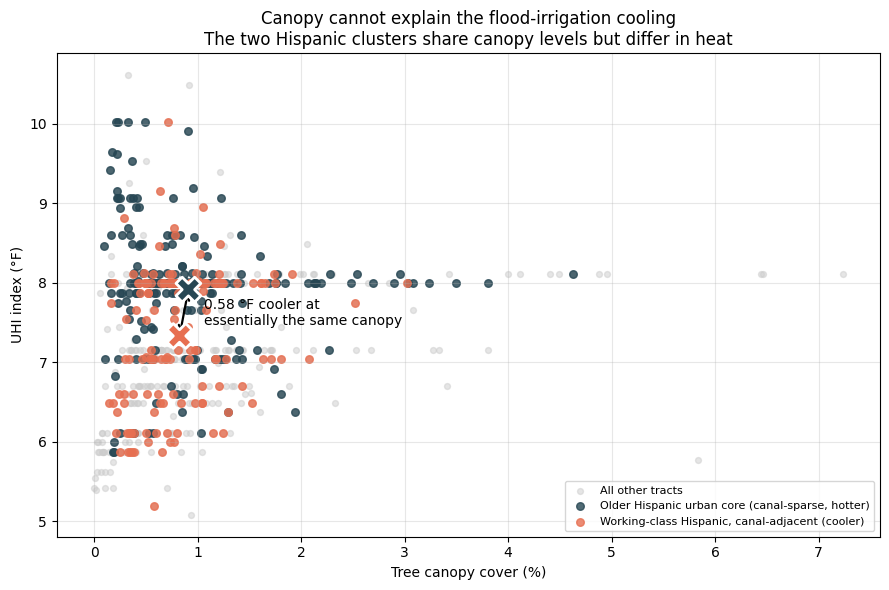

In [5]:
# Cell 5 — Visualize the mechanism test: canopy cannot explain the cooling gap
fig, ax = plt.subplots(figsize=(9, 6))

# All tracts as light background context
ax.scatter(tracts['canopy_pct'], tracts['uhi_index_f'],
           s=18, color='#cccccc', alpha=0.5, label='All other tracts')

core  = tracts[tracts['archetype'] == 'Older Hispanic urban core']
canal = tracts[tracts['archetype'] == 'Working-class Hispanic, canal-adjacent']
ax.scatter(core['canopy_pct'], core['uhi_index_f'], s=30, color='#264653', alpha=0.8,
           label='Older Hispanic urban core (canal-sparse, hotter)')
ax.scatter(canal['canopy_pct'], canal['uhi_index_f'], s=30, color='#e76f51', alpha=0.8,
           label='Working-class Hispanic, canal-adjacent (cooler)')

# Centroids
cx, cy = core['canopy_pct'].mean(), core['uhi_index_f'].mean()
ax_, ay = canal['canopy_pct'].mean(), canal['uhi_index_f'].mean()
ax.scatter([cx, ax_], [cy, ay], s=320, marker='X',
           color=['#264653', '#e76f51'], edgecolor='white', linewidth=2, zorder=5)

# Arrow between centroids: nearly vertical = same canopy, different heat
ax.annotate('', xy=(ax_, ay), xytext=(cx, cy),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.6))
ax.text(max(cx, ax_) + 0.15, (cy + ay) / 2,
        '0.58 °F cooler at\nessentially the same canopy',
        fontsize=10, ha='left', va='center')

ax.set_xlabel('Tree canopy cover (%)')
ax.set_ylabel('UHI index (°F)')
ax.set_title('Canopy cannot explain the flood-irrigation cooling\n'
             'The two Hispanic clusters share canopy levels but differ in heat')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Cell 6 — Save the canopy-augmented output (Notebook 02's tracts_analyzed.gpkg left untouched)
print('tracts type:', type(tracts).__name__, '| CRS:', tracts.crs)

out_path = ROOT / 'data' / 'processed' / 'tracts_analyzed_canopy.gpkg'
tracts.to_file(out_path, driver='GPKG')
print(f'Saved {len(tracts)} tracts (with canopy_pct) to {out_path}')

csv_path = ROOT / 'data' / 'processed' / 'tracts_analyzed_canopy.csv'
tracts.drop(columns='geometry').to_csv(csv_path, index=False)
print(f'Saved CSV to {csv_path}')

print('\n--- Notebook 03 canopy-mediation summary ---')
print('Canopy vs UHI (all 671 tracts):   Pearson r = +0.140 (confounded by neighborhood age)')
print('Two Hispanic clusters, canopy:    urban core 0.91% vs canal-adjacent 0.82% (Welch p = 0.154, n.s.)')
print('Cooling gap, no canopy control:   -0.583 degF')
print('Cooling gap, canopy controlled:   -0.580 degF (canopy coef +0.031, p = 0.641)')
print('Conclusion: tree canopy does NOT mediate the flood-irrigation cooling.')

tracts type: GeoDataFrame | CRS: EPSG:4269
Saved 671 tracts (with canopy_pct) to /Users/seanjayasekera/Documents/Data Science Projects/Hohokam Pattern/data/processed/tracts_analyzed_canopy.gpkg
Saved CSV to /Users/seanjayasekera/Documents/Data Science Projects/Hohokam Pattern/data/processed/tracts_analyzed_canopy.csv

--- Notebook 03 canopy-mediation summary ---
Canopy vs UHI (all 671 tracts):   Pearson r = +0.140 (confounded by neighborhood age)
Two Hispanic clusters, canopy:    urban core 0.91% vs canal-adjacent 0.82% (Welch p = 0.154, n.s.)
Cooling gap, no canopy control:   -0.583 degF
Cooling gap, canopy controlled:   -0.580 degF (canopy coef +0.031, p = 0.641)
Conclusion: tree canopy does NOT mediate the flood-irrigation cooling.
